# EDA - PWC Multiclass Dataset
Analisi esplorativa del dataset multiclasse estratto da Papers With Code (PWC).
Dataset: `../data/processed/pwc_ai_multiclass.csv`

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setup stile plot
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

In [7]:
# 1. Caricamento Dati
df_multiclass = pd.read_csv('../data/processed/pwc_ai_multiclass.csv')
print(f"Dimensioni dataset: {df_multiclass.shape}")
display(df_multiclass.head())

Dimensioni dataset: (395581, 2)


,description,label
0,Can evolving networks be inferred and modeled ...,Research
1,PAC-Bayes bounds have been proposed to get ris...,Research
2,This paper investigates the automated recognit...,Research
3,We analyze algorithms for approximating a func...,Research
4,In order to provide the right type of assistan...,Research


In [3]:
# 2. Controllo valori mancanti
print("Valori mancanti per colonna:")
print(df_multiclass.isnull().sum())

Valori mancanti per colonna:
description    3437
label             0
dtype: int64


/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_19527/3432389342.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_multiclass, y='label', order=df_multiclass['label'].value_counts().index, palette='viridis')


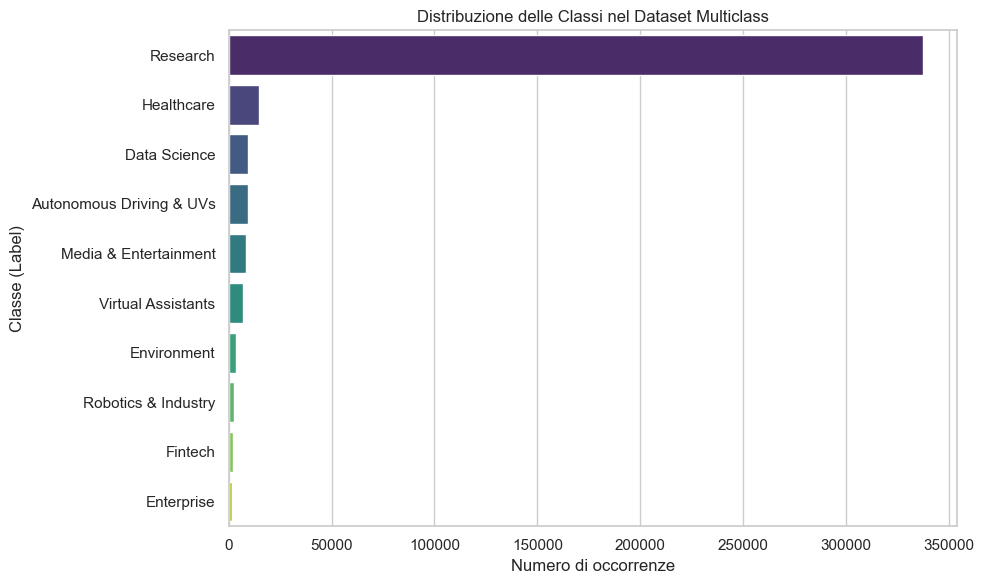

In [4]:
# 3. Distribuzione delle Classi (Label)
plt.figure(figsize=(10, 6))
sns.countplot(data=df_multiclass, y='label', order=df_multiclass['label'].value_counts().index, palette='viridis')
plt.title('Distribuzione delle Classi nel Dataset Multiclass')
plt.xlabel('Numero di occorrenze')
plt.ylabel('Classe (Label)')
plt.tight_layout()
plt.show()

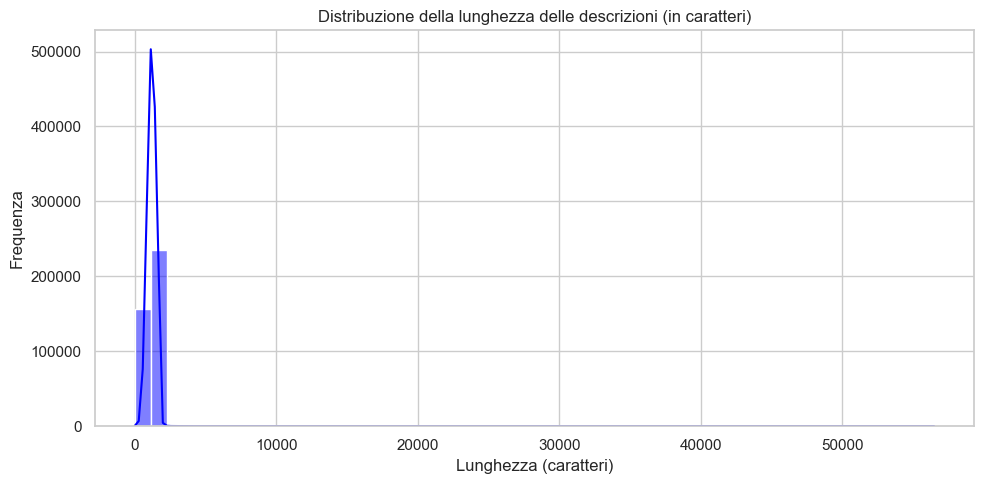

In [5]:
# 4. Analisi della lunghezza delle descrizioni
df_multiclass['desc_length'] = df_multiclass['description'].astype(str).str.len()

plt.figure(figsize=(10, 5))
sns.histplot(df_multiclass['desc_length'], bins=50, kde=True, color='blue')
plt.title('Distribuzione della lunghezza delle descrizioni (in caratteri)')
plt.xlabel('Lunghezza (caratteri)')
plt.ylabel('Frequenza')
plt.tight_layout()
plt.show()

# 6. Ri-classificazione della Categoria "Research"

I record classificati come `Research` sono spesso abstract di paper. Il gergo accademico fa finire l'articolo nella macro-categoria `Research` anche se il tema applicativo è un altro (es: Healthcare, NLP).
Eseguiamo una "seconda passata" sui record attualmente `Research` utilizzando keyword applicative per farli confluire nelle categorie corrette.

In [8]:
import re

# Definiamo regex più specializzate per intercettare i veri casi d'uso
# ignorando la terminologia accademica (paper, research, study, etc.)
refinement_regex = {
    "Healthcare": [r'\bhealthcare\b', r'\bmedical(?:ly)?\b', r'\bclinic(?:al|s)\b', r'\bdiseas(?:e|es)\b', 
                   r'\bpatien[ts]?\b', r'\behr[s]?\b', r'\bhealth[s]?\b', r'\bgenomi[cs]?\b', 
                   r'\bcancer[s]?\b', r'\btumo[ur]s?\b', r'\bdiagnos(?:is|tics|tically)\b'],
    "Media & Entertainment": [r'\bsocial\s+media\b', r'\bvideo[s]?\b', r'\bmusic\b', r'\bmovie[s]?\b', 
                              r'\bgam(?:e|es|ing)\b', r'\bdeepfake[s]?\b', r'\bfake\s+news\b', 
                              r'\bgenerative\s+art\b', r'\bmultimedia\b'],
    "Fintech": [r'\bfi[nn](?:ance|ancial)\b', r'\bbank(?:ing|s)\b', r'\btrading\b', r'\bstock[s]?\b', 
                r'\bfraud(?:ulent)?\b', r'\bcredit[s]?\b', r'\bcrypt(?:o|ocurrency)\b', r'\binsurance\b'],
    "Autonomous Driving & UVs": [r'\bautonomous\b', r'\bs[eè]lf[\-\s]?driving\b', r'\bvehicl[e|es]\b', 
                                 r'\bdrone[s]?\b', r'\buav[s]?\b', r'\btraffic\b', r'\badas\b'],
    "Robotics & Industry": [r'\brobot[s]?\b', r'\brobotic[s]?\b', r'\bindustr[y|ial]\b', r'\bmanufactur(?:e|ing)\b', 
                            r'\bsupply\s+chain\b', r'\biot\b', r'\bpredictive\s+maintenance\b', r'\bwarehouse\b'],
    "Environment": [r'\benvironmen[tal]?\b', r'\bclimat(?:e|ic)\b', r'\bagricultur[e|al]\b', r'\bsustainabilit[y]\b', 
                    r'\brecycl(?:e|ing)\b', r'\benergy\b', r'\bweather\b', r'\bpolluti(?:on|ants)\b'],
    "Virtual Assistants": [r'\bchatbot[s]?\b', r'\bdialog(?:ue)?\b', r'\bconversational\b', r'\bspeech\b', 
                           r'\bvoic(?:e|es)\b', r'\bllm[s]?\b', r'\bquestion\s+answering\b', r'\bassistant[s]?\b'],
    "Enterprise": [r'\benterpris(?:e|es)\b', r'\bhuman\s+resources\b', r'\bmarketing\b', r'\bcustomer[s]?\b', 
                   r'\brpa\b', r'\be-commerce\b', r'\bbusiness\b', r'\bsales\b'],
    "Data Science": [r'\bdata\s+science\b', r'\banomaly\s+detection\b', r'\bfeature\s+engineering\b', 
                     r'\bautoml\b', r'\bbig\s+data\b', r'\bdatabase[s]?\b']
}

compiled_refinements = {cat: re.compile('|'.join(kws), re.IGNORECASE) for cat, kws in refinement_regex.items()}

def refine_research_label(text):
    text_lower = str(text).lower()
    for cat, regex in compiled_refinements.items():
        if regex.search(text_lower):
            return cat
    return "Research" # Se non trovo nulla, rimane Research

# Contiamo quanti record prima della passata
mask_research = df_multiclass['label'] == 'Research'
print(f"Record classificati come 'Research' prima: {mask_research.sum()}")

# Applichiamo la funzione solo sui record attualmente in "Research"
df_multiclass.loc[mask_research, 'label'] = df_multiclass.loc[mask_research, 'description'].apply(refine_research_label)

# Verifichiamo l'impatto
new_mask_research = df_multiclass['label'] == 'Research'
diff = mask_research.sum() - new_mask_research.sum()
print(f"Record classificati come 'Research' dopo: {new_mask_research.sum()}")
print(f"Record ricollocati: {diff}")
print("\nNuova distribuzione:")
print(df_multiclass['label'].value_counts())

Record classificati come 'Research' prima: 337167
Record classificati come 'Research' dopo: 207854
Record ricollocati: 129313

Nuova distribuzione:
label
Research                    207854
Virtual Assistants           40514
Healthcare                   37352
Media & Entertainment        33321
Environment                  20481
Autonomous Driving & UVs     17705
Robotics & Industry          14629
Data Science                 13878
Fintech                       6787
Enterprise                    3060
Name: count, dtype: int64


/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_19527/3109740517.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_multiclass, y='label', order=df_multiclass['label'].value_counts().index, palette='magma')


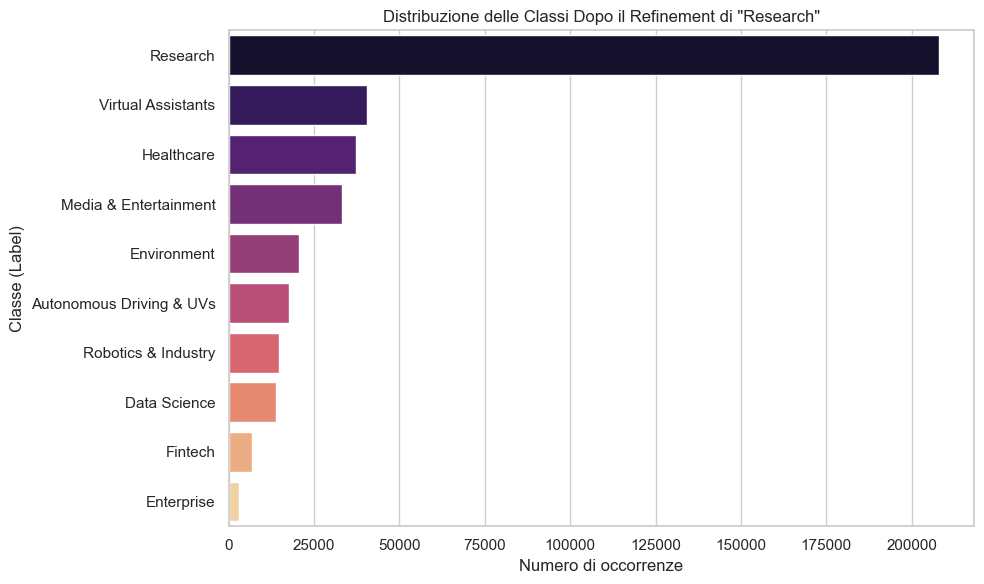

In [9]:
# 7. Grafico della Nuova Distribuzione
plt.figure(figsize=(10, 6))
sns.countplot(data=df_multiclass, y='label', order=df_multiclass['label'].value_counts().index, palette='magma')
plt.title('Distribuzione delle Classi Dopo il Refinement di "Research"')
plt.xlabel('Numero di occorrenze')
plt.ylabel('Classe (Label)')
plt.tight_layout()
plt.show()

In [10]:
# 8. Salvataggio 
# Sovrascriviamo o salviamo come nuovo
out_path = '../data/processed/pwc_ai_multiclass.csv'
df_multiclass.to_csv(out_path, index=False)
print(f"Nuovo dataset salvato in: {out_path}")

Nuovo dataset salvato in: ../data/processed/pwc_ai_multiclass.csv
